# MEGPypes Run Workflow Tutorial

This notebook shows how to interact with the high-level runner endpoint in `src/megpypes/runner.py`.

You will learn how to:
- load and inspect the YAML config (`demos/config_example.yaml`)
- create a `MegPypesRunner` instance
- build and inspect a workflow before executing
- run the pipeline with default and advanced overrides
- launch the Streamlit QC report app from Python

## 1. Environment Setup

This cell ensures paths resolve correctly whether you run the notebook from the project root or from the demos folder.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "demos":
    os.chdir(cwd.parent)

print(f"Current working directory: {Path.cwd()}")

Current working directory: /Users/peli/Projects/Repositories/MEGPypes


## Load sample data
https://www.fil.ion.ucl.ac.uk/spm/data/mmfaces/

https://mne.tools/1.8/documentation/datasets


In [2]:
import mne
data_path = Path("data").resolve()
data_dir = data_path / "MNE-spm-face"
if not data_dir.exists():
    print(f"SPM face dataset not found, downloading to: {data_path}")
    mne.datasets.spm_face.data_path(path=data_path)
else:
    print(f"SPM face dataset dir already exists: {data_dir.resolve()}")

SPM face dataset dir already exists: /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face


## Inspect data to extract config variables

In [3]:
path = data_dir / "MEG/spm/SPM_CTF_MEG_example_faces1_3D.ds"
print(f"SPM face dataset path: {path}")
raw = mne.io.read_raw_ctf(path, preload=True)
print(raw.info)

# find event channels
stim_channels = mne.pick_types(raw.info, meg=False, stim=True)
print(f"Stim channels: {[raw.info['ch_names'][i] for i in stim_channels]}")
stim_channel_ids = [raw.info['ch_names'][i] for i in stim_channels]
# find the trigger ids
events = mne.find_events(raw, stim_channel=stim_channel_ids)
print(f"Found events: {events[:5]} ...")


SPM face dataset path: /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face/MEG/spm/SPM_CTF_MEG_example_faces1_3D.ds
ds directory : /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face/MEG/spm/SPM_CTF_MEG_example_faces1_3D.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
      -0.90   72.01    0.00 mm <->   -0.90   72.01   -0.00 mm (orig :  -43.09   61.46 -252.17 mm) diff =    0.000 mm
       0.90  -72.01    0.00 mm <->    0.90  -72.01   -0.00 mm (orig :   53.49  -45.24 -258.02 mm) diff =    0.000 mm
      98.30    0.00    0.00 mm <->   98.30   -0.00    0.00 mm (orig :   78.60   72.16 -241.87 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face/MEG/spm/SPM_CTF_MEG

In [4]:
from collections import Counter
import json

# Count all event IDs detected from the selected stim channels.
event_counts = Counter(events[:, 2].tolist())
print("Event ID counts:")
for event_id, n in sorted(event_counts.items()):
    print(f"  {event_id}: {n}")

# Generic fallback labels for any dataset.
def _default_label(event_id: int) -> str:
    return f"event_{event_id}"

# SPM face convention shortcut (from dataset docs / SPM tutorial usage).
spm_face_labels = {
    1: "faces",
    2: "scrambled",
    3: "button",
    255: "sync_or_padding",
}

# Build suggested mapping.
# Keep only IDs with enough samples by default; adjust threshold if needed.
min_count = 5
candidate_ids = [eid for eid, count in sorted(event_counts.items()) if count >= min_count]

suggested_mapping = {
    str(eid): [spm_face_labels.get(eid, _default_label(eid)), -0.2, 0.8]
    for eid in candidate_ids
}

print("\nSuggested event_mapping (generic):")
print(json.dumps(suggested_mapping, indent=2))

# Optional: strict 2-condition SPM-style mapping.
spm_two_condition_mapping = {
    "1": ["faces", -0.2, 0.8],
    "2": ["scrambled", -0.2, 0.8],
}
print("\nSPM two-condition mapping:")
print(json.dumps(spm_two_condition_mapping, indent=2))

Event ID counts:
  1: 84
  2: 84
  3: 4
  255: 172

Suggested event_mapping (generic):
{
  "1": [
    "faces",
    -0.2,
    0.8
  ],
  "2": [
    "scrambled",
    -0.2,
    0.8
  ],
  "255": [
    "sync_or_padding",
    -0.2,
    0.8
  ]
}

SPM two-condition mapping:
{
  "1": [
    "faces",
    -0.2,
    0.8
  ],
  "2": [
    "scrambled",
    -0.2,
    0.8
  ]
}


After some research into the dataset we found that the channel `UPPT001` has two the two conditions faces and scrambled at triggers 1 and 2.

In the config we can now set the `epoching > iterables > event_mapping`
to 
```python
{
    "1": ["faces", -0.2, 0.8],
    "2": ["scrambled", -0.2, 0.8]
}
```

and the `epoching > args > epoch > stim_channels`
to 
`UPPT001`



## 2. Inspect Config

In [5]:
import yaml

config_path = Path("demos/config_example.yaml")
with config_path.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

print("Top-level keys:", list(config.keys()))
print("paths keys:", list(config["paths"].keys()))
print("workflow keys:", list(config["workflow"].keys()))
print("pipeline_config keys:", list(config["pipeline_config"].keys()))

Top-level keys: ['paths', 'workflow', 'pipeline_config']
paths keys: ['basedir', 'workdir', 'outputdir', 'file_templates', 'iterable_fields', 'iterable_values']
workflow keys: ['plugin', 'n_workers', 'auto_workers']
pipeline_config keys: ['initial_preproc', 'artifact_rejection', 'auto_ica', 'epoching']


## 3. YAML Structure Walkthrough

### paths
- `basedir`: input data root
- `workdir`: Nipype working directory
- `outputdir`: final output location
- `file_templates`: SelectFiles template dictionary
- `iterable_fields` and `iterable_values`: iteration dimensions and values

### workflow
- `plugin`: execution backend (for example `Linear`, `MultiProc`)
- `n_workers`: number of processes when supported
- `auto_workers`: whether to auto-compute worker count

### pipeline_config
Contains per-node step flags and arguments for:
- `initial_preproc`
- `artifact_rejection`
- `auto_ica`
- `epoching`

## 4. Create the Runner

`MegPypesRunner` is the high-level interactive endpoint for this pipeline.

In [6]:
from megpypes.runner import MegPypesRunner

runner = MegPypesRunner.from_yaml(config_path)
print("Runner created from:", runner.config_path)
print("Default plugin:", runner.workflow_config.get("plugin"))

Runner created from: /Users/peli/Projects/Repositories/MEGPypes/demos/config_example.yaml
Default plugin: Linear


## 5. Build the Workflow (Without Running Yet)

This is useful when you want to inspect or customize before execution.

In [7]:
wf = runner.create_workflow()
print("Workflow name:", wf.name)
print("Workflow base dir:", wf.base_dir)

graph_path = runner.write_graph(wf)
print("Workflow graph path:", graph_path)

No 'subject' iterable field was provided. Injecting synthetic subject axis with default value '01'.


raw_dir /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face
Iterating over fields: ['session', 'subject']
Provided iterable values: {'subject': ['1'], 'session': ['1', '2']}
Processing iterable field: session
Using custom values for field: session
Processing iterable field: subject
Using custom values for field: subject
Final iterables dict: {'session': ['1', '2'], 'subject': ['1']}
Valid inputs for initial_preproc: {'trait_added', 'max_buffer', 'in_file', 'gradcomp_auto', 'gradcomp_order', 'out_file', 'trait_modified', 'stim_channel', 'h_freq', 'min_buffer', 'l_freq'}
Step 'crop' argument 'stim_channel': None
Step 'crop' argument 'min_buffer': -1
Step 'crop' argument 'max_buffer': 1
Step 'filter' argument 'l_freq': 1.0
Step 'filter' argument 'h_freq': 100
Step 'gradcomp' argument 'gradcomp_auto': True
Step 'gradcomp' argument 'order': None
Valid inputs for artifact_rejection: {'ica_random_state', 'ica_h_freq', 'in_file', 'ica_method', 'detect_line_freq', 'trait_added', 'ica_f

## 6. Run the Pipeline (Only from config)

Use config defaults for plugin and workers.

NiPype caches the stepwise results in the ``workdir`` directory and restarts the workflow from the last saved data. 
Meaningful outputs are stored in the ``output`` directory in a BIDS format.

To completely re-run a workflow from start you can easily delete the "workdir" directory and run again.

Execute when ready (this can take time):

/Users/peli/Projects/Repositories/MEGPypes/.venv/lib/python3.13/site-packages/nipype/external/cloghandler.py:145: UserWarning: The given 'filename' should be an absolute path.  If your application calls os.chdir(), your logs may get messed up. Use 'supress_abs_warn=True' to hide this message.
  warn(
No 'subject' iterable field was provided. Injecting synthetic subject axis with default value '01'.


raw_dir /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face
Iterating over fields: ['session', 'subject']
Provided iterable values: {'subject': ['1'], 'session': ['1', '2']}
Processing iterable field: session
Using custom values for field: session
Processing iterable field: subject
Using custom values for field: subject
Final iterables dict: {'session': ['1', '2'], 'subject': ['1']}
260407-14:06:02,483 nipype.workflow DEBUG:
	 (megpreproc.infosource, megpreproc.selectfiles): No edge data
260407-14:06:02,484 nipype.workflow DEBUG:
	 (megpreproc.infosource, megpreproc.selectfiles): new edge data: {'connect': [('session', 'session')]}
Valid inputs for initial_preproc: {'trait_added', 'max_buffer', 'in_file', 'gradcomp_auto', 'gradcomp_order', 'out_file', 'trait_modified', 'stim_channel', 'h_freq', 'min_buffer', 'l_freq'}
Step 'crop' argument 'stim_channel': None
Step 'crop' argument 'min_buffer': -1
Step 'crop' argument 'max_buffer': 1
Step 'filter' argument 'l_freq': 1.0
Step 'f

2026-04-07 14:06:02,780 [INFO] megpypes.interfaces.initpreproc: WF: Initial Preproc | In-File: /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face/MEG/spm/SPM_CTF_MEG_example_faces1_3D.ds/SPM_CTF_MEG_example_faces1_3D.meg4


ds directory : /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face/MEG/spm/SPM_CTF_MEG_example_faces1_3D.ds
    res4 data read.
    hc data read.
    Separate EEG position data file not present.
    Quaternion matching (desired vs. transformed):
      -0.90   72.01    0.00 mm <->   -0.90   72.01   -0.00 mm (orig :  -43.09   61.46 -252.17 mm) diff =    0.000 mm
       0.90  -72.01    0.00 mm <->    0.90  -72.01   -0.00 mm (orig :   53.49  -45.24 -258.02 mm) diff =    0.000 mm
      98.30    0.00    0.00 mm <->   98.30   -0.00    0.00 mm (orig :   78.60   72.16 -241.87 mm) diff =    0.000 mm
    Coordinate transformations established.
    Polhemus data for 3 HPI coils added
    Device coordinate locations for 3 HPI coils added
    Measurement info composed.
Finding samples for /Users/peli/Projects/Repositories/MEGPypes/data/MNE-spm-face/MEG/spm/SPM_CTF_MEG_example_faces1_3D.ds/SPM_CTF_MEG_example_faces1_3D.meg4: 
    System clock channel is available, checking which samples are 

2026-04-07 14:06:04,865 [INFO] megpypes.interfaces.initpreproc: OUT FILE PATH: initial-preproc_raw.fif


...

260407-14:07:44,338 nipype.workflow INFO:
	 [Node] Finished "epoching", elapsed time 0.491975s.
260407-14:07:44,339 nipype.workflow DEBUG:
	 Needed files: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_1_event_label_faces_event_tmax_0.8_event_tmin_-0.2/epoching/20260407T140744-faces-epoched_epo.fif;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_1_event_label_faces_event_tmax_0.8_event_tmin_-0.2/epoching/20260407T140744-faces-raw_epochs.png;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_1_event_label_faces_event_tmax_0.8_event_tmin_-0.2/epoching/_0xdf8315c6fc0f8a7c04a7c707156f1a85_unfinished.json;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_1_event_label_faces_event_tmax_0.8_event_tmin_-0.2/epoching/_inputs.pklz;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_

2026-04-07 14:07:44,346 [INFO] megpypes.interfaces.epoching: NODE: Epoching | In-File: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/artifact_rejection/20260407T140742-artifact-cleaned_raw.fif
2026-04-07 14:07:44,346 [INFO] megpypes.interfaces.epoching: Epoching for event: scrambled
2026-04-07 14:07:44,346 [INFO] megpypes.interfaces.epoching: id: 2, tmin: -0.2, tmax: 0.8


Opening raw data file /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/artifact_rejection/20260407T140742-artifact-cleaned_raw.fif...
    Read 5 compensation matrices
    Range : 891 ... 300518 =      1.856 ...   626.079 secs
Ready.
Current compensation grade : 0
Reading 0 ... 299627  =      0.000 ...   624.223 secs...
Finding events on: UPPT001
172 events found on stim channel UPPT001
Event IDs: [1 2 3]
Not setting metadata
84 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 84 events and 481 original time points ...
0 bad epochs dropped
Not setting metadata
84 matching events found
No baseline correction applied
0 projection items activated
combining channels using "mean"


2026-04-07 14:07:44,833 [INFO] megpypes.interfaces.epoching: OUT FILE PATH: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_2_event_label_scrambled_event_tmax_0.8_event_tmin_-0.2/epoching/20260407T140744-scrambled-epoched_epo.fif
2026-04-07 14:07:44,861 [INFO] megpypes.interfaces.epoching: Saved: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_2_event_label_scrambled_event_tmax_0.8_event_tmin_-0.2/epoching/20260407T140744-scrambled-epoched_epo.fif


260407-14:07:44,862 nipype.workflow INFO:
	 [Node] Finished "epoching", elapsed time 0.515804s.
260407-14:07:44,862 nipype.workflow DEBUG:
	 Needed files: /Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_2_event_label_scrambled_event_tmax_0.8_event_tmin_-0.2/epoching/20260407T140744-scrambled-epoched_epo.fif;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_2_event_label_scrambled_event_tmax_0.8_event_tmin_-0.2/epoching/20260407T140744-scrambled-raw_epochs.png;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_2_event_label_scrambled_event_tmax_0.8_event_tmin_-0.2/epoching/_0x7def17e5ba5966539b36ab5bbdb6bd33_unfinished.json;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_session_2_subject_1/_event_id_2_event_label_scrambled_event_tmax_0.8_event_tmin_-0.2/epoching/_inputs.pklz;/Users/peli/Projects/Repositories/MEGPypes/workdir/megpreproc/_sessio

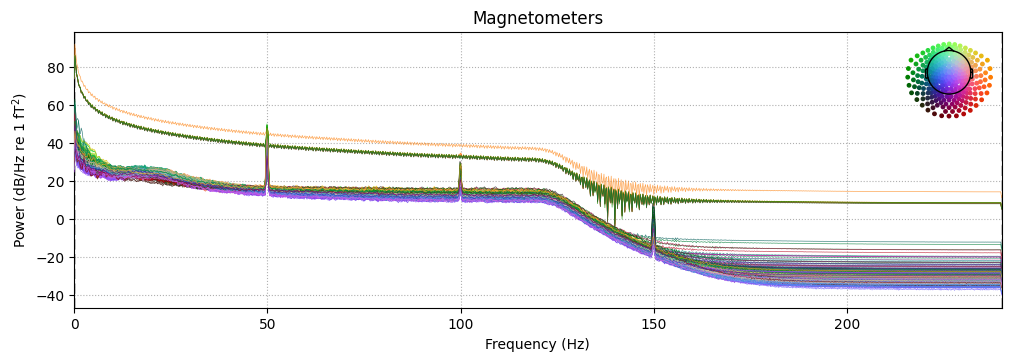

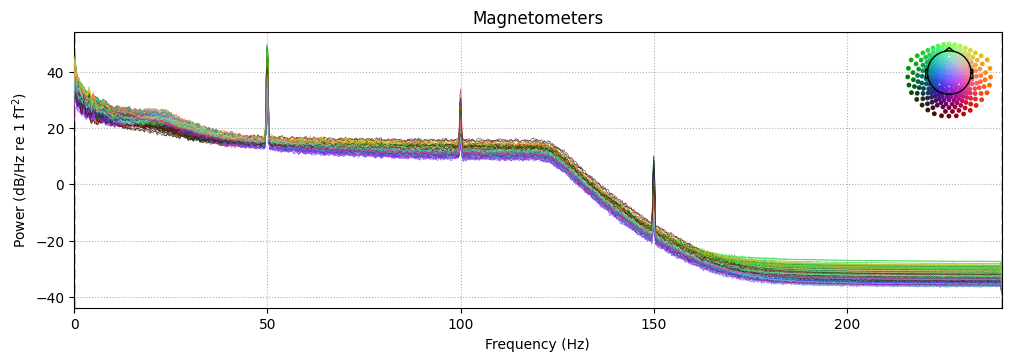

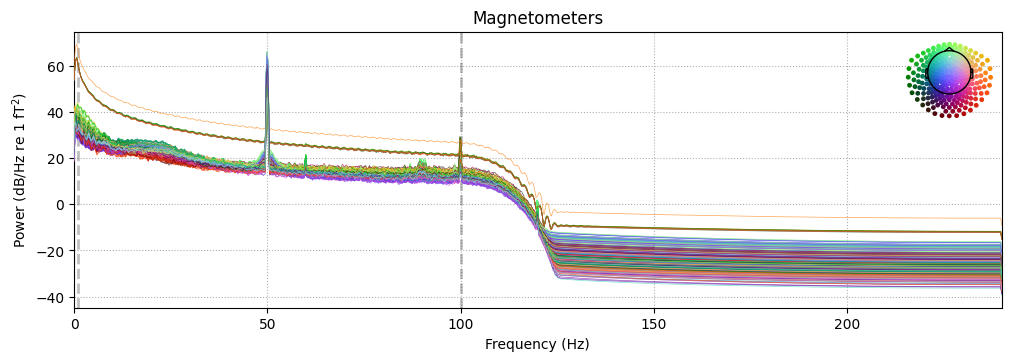

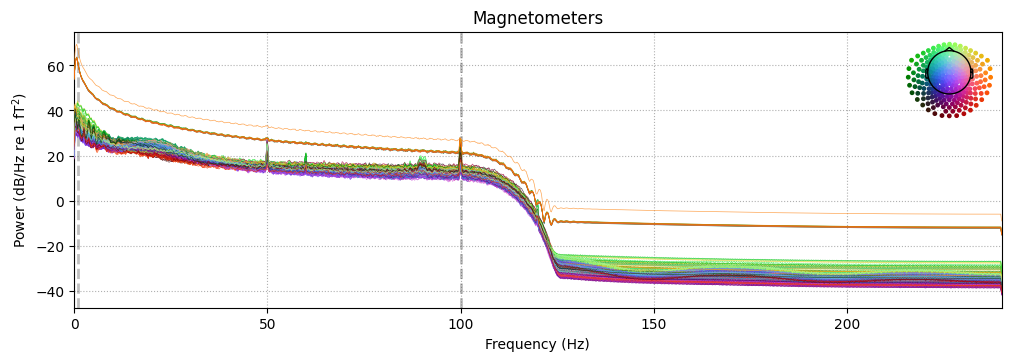

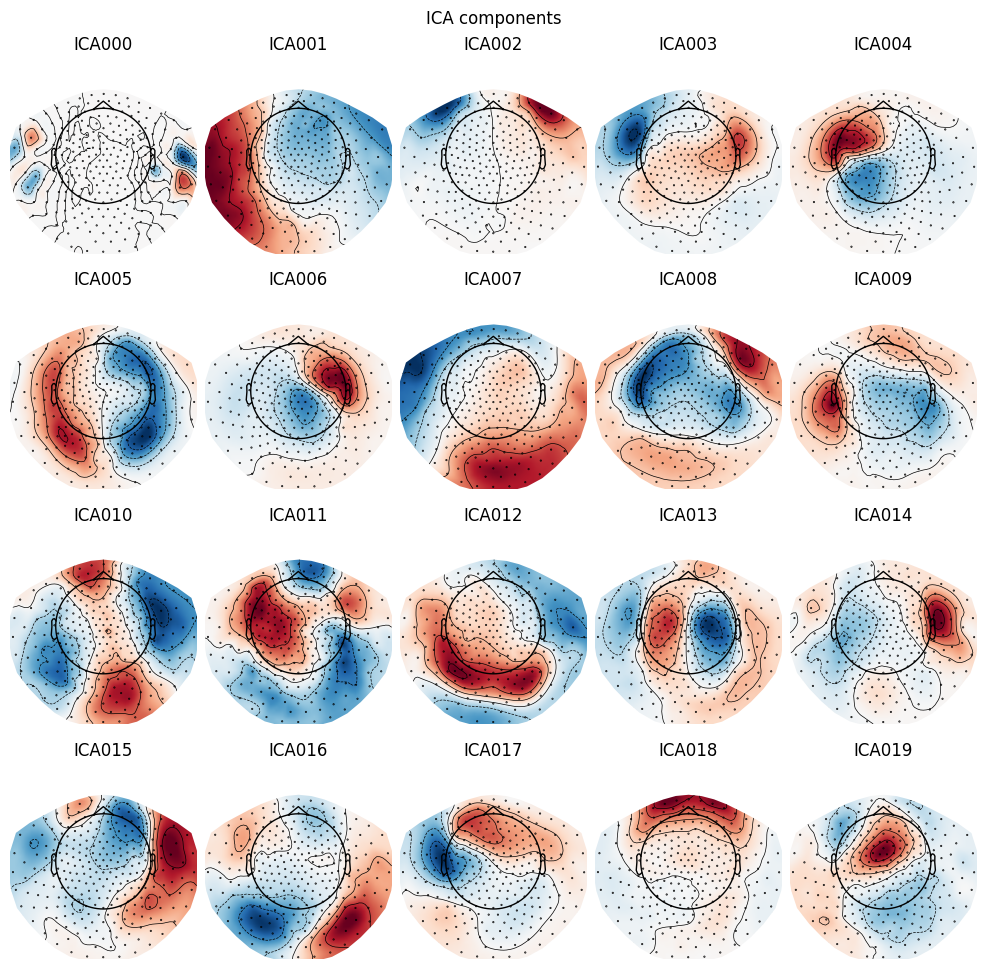

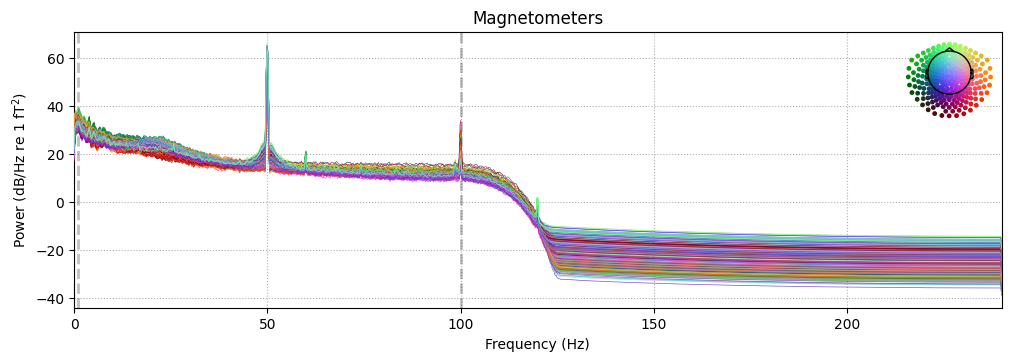

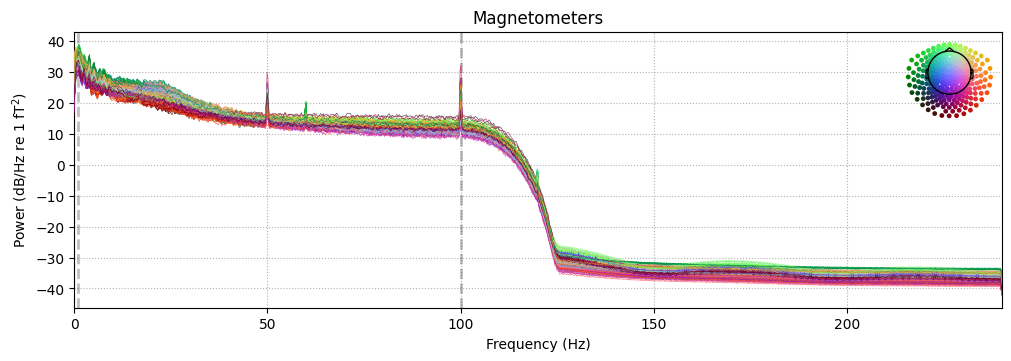

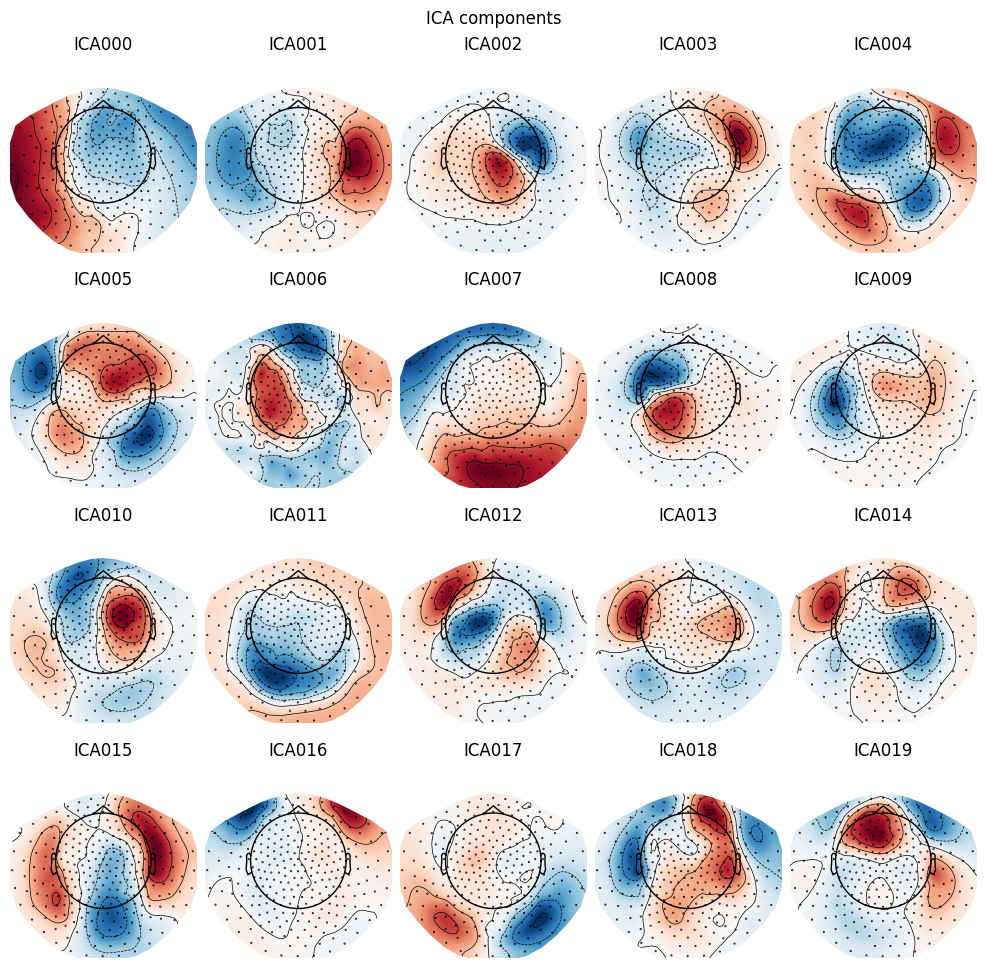

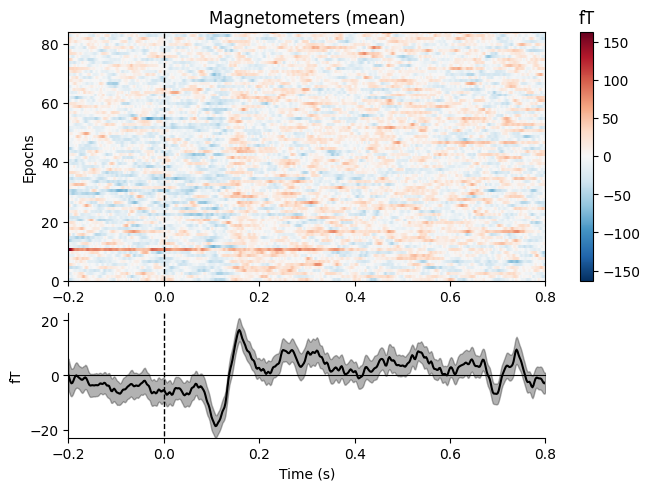

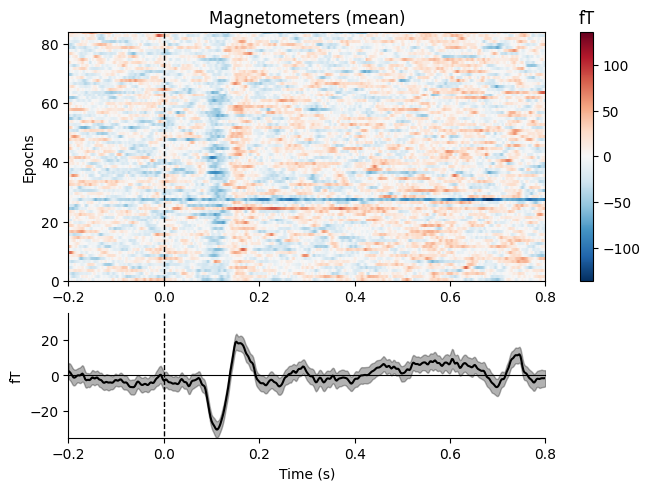

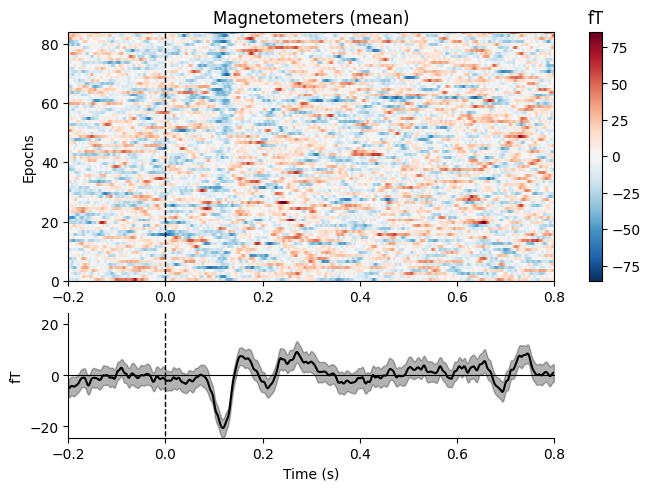

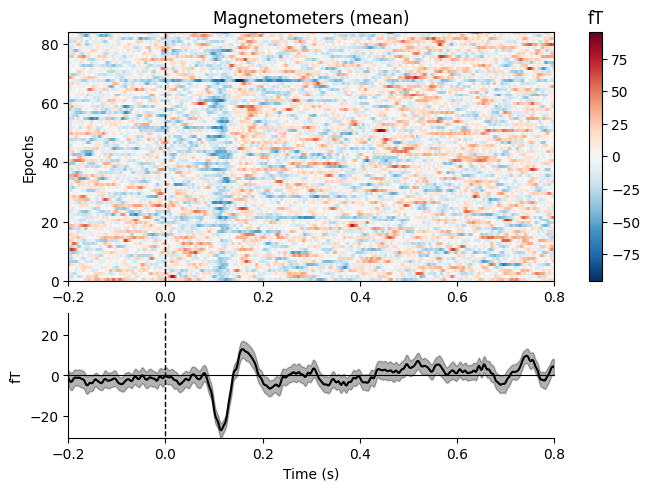

In [8]:
run_info = runner.run(write_graph=True)
print(f"Plugin: {run_info.plugin}")
print(f"Workers: {run_info.n_workers}")
print(f"Graph: {runner.graph_path}")

## 7. Advanced Overrides

Override iterable values, then run with explicit execution settings.

Uncomment and run to try:

In [9]:
# create iterables list
#subs = [f"subject_{i}" for i in range(0, 3)]
#print("Subjects to process:", subs)

#custom_wf = runner.create_workflow(
#   paths_override={
#        "epoching"
#    }
#)

#print("Custom workflow prepared for one subject/session.")

#advanced_run = runner.run(
#    workflow=custom_wf,
#    plugin="Linear",
#    n_workers=4,
#    write_graph=True
#)
#print(advanced_run)

## 8. Launch the Streamlit Report App from Notebook

The runner can start the report app process and point it to a specific output root.

In [10]:
report_proc = runner.launch_report_app(report_root="output/", port=8501, headless=True)
print("Report URL:", runner.report_url(port=8501))

Report URL: http://127.0.0.1:8501


In [7]:
# To stop later:
runner.stop_report_app()

In [12]:
runner._report_process

<Popen: returncode: None args: ['/Users/peli/Projects/Repositories/MEGPypes/...>

## 9. Practical Notes

- Keep `demos/config_example.yaml` under version control as your reproducible baseline.
- Use overrides for one-off exploratory runs.
- If running from JupyterLab on a remote machine, set `host="0.0.0.0"` for report access.
- For large datasets, prefer `MultiProc` with explicit worker limits based on RAM/CPU.